# Length correction robustness

Robustness of the sign-reversal result to alternative length-correction
parametrisations and to the choice of reasoning-phase prefix cut, plus the
residual diagnostic for the canonical cubic-log fit.

In [1]:
import os
from pathlib import Path

_root = Path.cwd()
while not (_root / 'pyproject.toml').exists() and _root.parent != _root:
    _root = _root.parent
os.chdir(_root)

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

mpl.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'font.size': 9,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 8,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

DATA = Path('data/processed')
OUT_FIGS = Path('figures')
OUT_FIGS.mkdir(parents=True, exist_ok=True)

DOMAIN_ORDER = ['code', 'math', 'sat']
DOMAIN_LABEL = {'code': 'Code', 'math': 'Math', 'sat': 'SAT'}
PAPER_LABEL = {
    'deepseek-r1-7b': 'DS-R1-7B', 'deepseek-r1-14b': 'DS-R1-14B',
    'deepseek-r1-32b': 'DS-R1-32B', 'qwq-32b': 'QwQ-32B',
    'r1-distill-llama-8b': 'R1-Llama-8B', 'phi-4-reasoning': 'Phi-4-R',
    'qwen-7b': 'Qwen-7B', 'qwen-14b': 'Qwen-14B', 'qwen-32b': 'Qwen-32B',
    'llama-8b': 'Llama-8B', 'phi-4': 'Phi-4',
}
REASONING_ORDER = ['deepseek-r1-7b', 'deepseek-r1-14b', 'deepseek-r1-32b',
                   'qwq-32b', 'r1-distill-llama-8b', 'phi-4-reasoning']
BASELINE_ORDER = ['qwen-7b', 'qwen-14b', 'qwen-32b', 'llama-8b', 'phi-4']
MODEL_ORDER = REASONING_ORDER + BASELINE_ORDER
PAPER_LABELS = [PAPER_LABEL[m] for m in MODEL_ORDER]


## Generate analysis inputs

When `IRT_RESULTS_ROOT` points at a populated `data/results/` tree, the cells
below regenerate `data/processed/03_*.parquet` from per-model
`trajectory_summaries.parquet` and `data/results/segmentation_validation/`.


In [2]:
# >>> generation-marker <<<
import numpy as np
from scipy.stats import spearmanr

RESULTS = Path(os.environ.get('IRT_RESULTS_ROOT', 'data/results'))
PROCESSED = Path('data/processed')
REGEN = RESULTS.exists() and any(RESULTS.rglob('trajectories/trajectory_summaries.parquet'))
print(f'regenerate from raw? {REGEN}  (IRT_RESULTS_ROOT={RESULTS})')


regenerate from raw? False  (IRT_RESULTS_ROOT=data/results)


### Six length-correction methods


In [3]:
# Build 03_length_correction_variants.parquet by applying 6 length-correction
# methods to each metric per (pair, role, model, domain). Long format. Each correlation
# is computed per layer and reported as the MEDIAN ACROSS the 5 sampled layers.
HIDDEN_STATE_MODELS = ['deepseek-r1-7b', 'deepseek-r1-14b', 'deepseek-r1-32b',
                      'r1-distill-llama-8b', 'qwq-32b', 'phi-4-reasoning',
                      'qwen-7b', 'qwen-14b', 'qwen-32b', 'llama-8b', 'phi-4']
REASONING = set(HIDDEN_STATE_MODELS[:6])
PAIR_LABEL = {
    'deepseek-r1-7b': 'Qwen-7B', 'qwen-7b': 'Qwen-7B',
    'deepseek-r1-14b': 'Qwen-14B', 'qwen-14b': 'Qwen-14B',
    'deepseek-r1-32b': 'Qwen-32B', 'qwen-32b': 'Qwen-32B',
    'qwq-32b': 'QwQ-32B',
    'r1-distill-llama-8b': 'Llama-8B', 'llama-8b': 'Llama-8B',
    'phi-4-reasoning': 'Phi-4', 'phi-4': 'Phi-4',
}
METRICS = {'D': 'directness', 'V': 'curvature_std', 'T': 'twonn_dim', 'P': 'pca_dim_90'}
METHODS = ['raw', 'log', 'invsqrt', 'loglog', 'cubic-log', 'binned']

def _correct(y, n_tokens, method):
    """Length-correct y given n_tokens. Returns residual."""
    log_n = np.log(n_tokens)
    if method == 'raw':
        return y
    if method == 'log':
        x = log_n
    elif method == 'invsqrt':
        x = 1.0 / np.sqrt(n_tokens)
    elif method == 'loglog':
        # log Y ~ log N; subtract that linear part
        ly = np.log(np.maximum(y, 1e-12))
        X = np.column_stack([np.ones_like(log_n), log_n])
        coef, *_ = np.linalg.lstsq(X, ly, rcond=None)
        return np.exp(ly - X @ coef)
    elif method == 'cubic-log':
        x = np.column_stack([log_n, log_n**2, log_n**3])
    elif method == 'binned':
        bins = pd.qcut(log_n, q=5, labels=False, duplicates='drop')
        out = np.empty_like(y, dtype=float)
        for b in np.unique(bins):
            mask = bins == b
            out[mask] = y[mask] - y[mask].mean()
        return out
    else:
        raise ValueError(method)
    if x.ndim == 1:
        X = np.column_stack([np.ones_like(x), x])
    else:
        X = np.column_stack([np.ones(len(x)), x])
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    return y - X @ coef

if REGEN:
    diffs = pd.read_parquet(PROCESSED / '01_difficulties.parquet').copy()
    diffs['domain'] = diffs['item_id'].str.split('_', n=1).str[0]
    diffs['problem_id'] = diffs['item_id'].str.split('_', n=1).str[1]
    diff_map = diffs.set_index(['domain', 'problem_id'])['difficulty']
    rows = []
    for model in HIDDEN_STATE_MODELS:
        for dom in DOMAIN_ORDER:
            p = RESULTS / dom / model / 'trajectories' / 'trajectory_summaries.parquet'
            if not p.exists():
                continue
            df = pd.read_parquet(p)
            layer_aggs = []
            for L in sorted(df['layer'].unique()):
                agg = (df[df['layer'] == L]
                       .groupby('problem_id')
                       .agg({c: 'mean' for c in METRICS.values()} | {'n_tokens': 'mean'})
                       .reset_index())
                agg['difficulty'] = agg['problem_id'].map(lambda pid: diff_map.get((dom, pid), np.nan))
                layer_aggs.append(agg.dropna(subset=['difficulty']))
            n_problems = len(layer_aggs[-1]) if layer_aggs else 0
            for metric_key, col in METRICS.items():
                for method in METHODS:
                    vals = []
                    for agg in layer_aggs:
                        y = agg[col].astype(float).values
                        if len(y) < 10 or np.isnan(y).any():
                            continue
                        n_tokens = agg['n_tokens'].astype(float).values
                        diff_v = agg['difficulty'].astype(float).values
                        vals.append(spearmanr(_correct(y, n_tokens, method), diff_v)[0])
                    if not vals:
                        continue
                    rows.append({
                        'pair': PAIR_LABEL[model],
                        'role': 'r1' if model in REASONING else 'base',
                        'model': model, 'domain': dom,
                        'n': int(n_problems),
                        'metric': metric_key, 'method': method,
                        'rho_perp': float(np.median(vals)),
                    })
    pd.DataFrame(rows).to_parquet(PROCESSED / '03_length_correction_variants.parquet', index=False)
    print(f'rebuilt 03_length_correction_variants.parquet ({len(rows)} rows, median across layers)')
else:
    print('using shipped 03_length_correction_variants.parquet')

using shipped 03_length_correction_variants.parquet


### Prefix sensitivity


In [4]:
# Copy segmentation prefix-sensitivity from upstream aggregation.
if REGEN:
    src = RESULTS / 'segmentation_validation' / 'sensitivity_rho.parquet'
    if src.exists():
        pd.read_parquet(src).to_parquet(PROCESSED / '03_prefix_sensitivity.parquet', index=False)
        print(f'copied {src.name} -> 03_prefix_sensitivity.parquet')
    else:
        print(f'segmentation_validation not found at {src}; using shipped cache')
else:
    print('using shipped 03_prefix_sensitivity.parquet')


using shipped 03_prefix_sensitivity.parquet


### Cubic-log residual diagnostics


In [5]:
# Cubic-log residuals for deepseek-r1-7b on code at peak layer.
if REGEN:
    p = RESULTS / 'code' / 'deepseek-r1-7b' / 'trajectories' / 'trajectory_summaries.parquet'
    if p.exists():
        df = pd.read_parquet(p)
        peak = int(df['layer'].max())
        df = df[df['layer'] == peak]
        agg = df.groupby('problem_id').agg({c: 'mean' for c in METRICS.values()} | {'n_tokens': 'mean'}).reset_index()
        log_n = np.log(agg['n_tokens'].astype(float).values)
        rows = []
        for label, col in [('Directness', 'directness'), ('Curvature std', 'curvature_std'),
                            ('TwoNN dim', 'twonn_dim'), ('PCA-90', 'pca_dim_90')]:
            y = agg[col].astype(float).values
            coef = np.polyfit(log_n, y, deg=3)
            resid = y - np.polyval(coef, log_n)
            rho, _ = spearmanr(resid, log_n)
            for ln, r in zip(log_n, resid):
                rows.append({'metric': label, 'log_n': float(ln), 'residual': float(r),
                             'spearman_rho': float(rho)})
        pd.DataFrame(rows).to_parquet(PROCESSED / '03_residual_diagnostics.parquet', index=False)
        print(f'rebuilt 03_residual_diagnostics.parquet ({len(rows)} rows)')
    else:
        print(f'r1-7b code summary not found; using shipped cache')
else:
    print('using shipped 03_residual_diagnostics.parquet')


using shipped 03_residual_diagnostics.parquet


---


## Length correction comparison (`length_correction.pdf`)

For each (pair, role, domain, metric), ρ⟂ under four length-correction families.


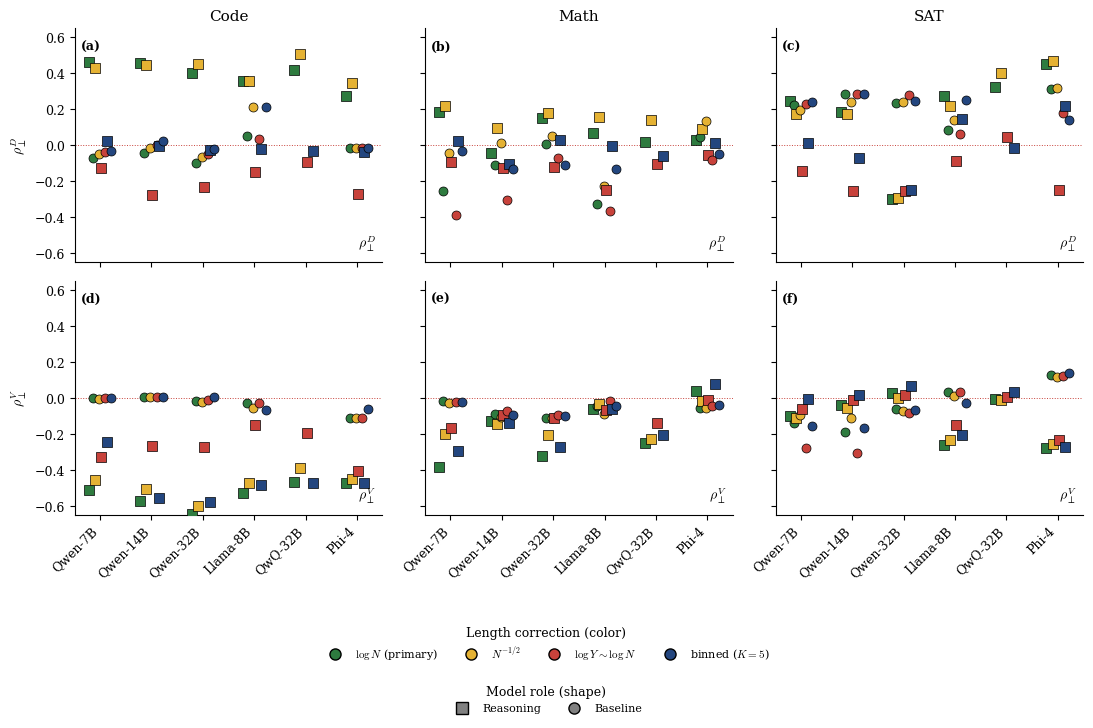

In [6]:
df_v = pd.read_parquet(DATA / '03_length_correction_variants.parquet')

METHODS = ['log', 'invsqrt', 'loglog', 'binned']
METHOD_LABEL = {'log': r'$\log N$ (primary)', 'invsqrt': r'$N^{-1/2}$',
                'loglog': r'$\log Y\sim\log N$', 'binned': r'binned ($K{=}5$)'}
METHOD_COLOUR = {'log': '#2E7B3F', 'invsqrt': '#E5B233',
                 'loglog': '#C8423B', 'binned': '#23467F'}
PAIR_ORDER = ['Qwen-7B', 'Qwen-14B', 'Qwen-32B', 'Llama-8B', 'QwQ-32B', 'Phi-4']
PANEL_LETTERS = list('abcdef')

fig, axes = plt.subplots(2, 3, figsize=(11, 6.5), sharex=True, sharey=True)
for row, metric in enumerate(['D', 'V']):
    for col, dom in enumerate(DOMAIN_ORDER):
        ax = axes[row, col]
        sub = df_v[(df_v['metric'] == metric) & (df_v['domain'] == dom) & (df_v['method'].isin(METHODS))]
        for i, p in enumerate(PAIR_ORDER):
            for j, method in enumerate(METHODS):
                dx = (j - 1.5) * 0.12
                for role, marker in [('r1', 's'), ('base', 'o')]:
                    if role == 'base':
                        dx_role = dx + 0.04
                    else:
                        dx_role = dx - 0.04
                    rr = sub[(sub['pair'] == p) & (sub['role'] == role) & (sub['method'] == method)]
                    if rr.empty:
                        continue
                    ax.scatter([i + dx_role], rr['rho_perp'].values, marker=marker,
                               c=METHOD_COLOUR[method], edgecolor='black', s=42, lw=0.5, zorder=3)
        ax.axhline(0, color='#C8423B', ls=':', lw=0.7)
        ax.set_xticks(range(len(PAIR_ORDER)))
        ax.set_xticklabels(PAIR_ORDER, rotation=45, ha='right')
        ax.set_ylim(-0.65, 0.65)
        if row == 0:
            ax.set_title(DOMAIN_LABEL[dom])
        letter = PANEL_LETTERS[row * 3 + col]
        ax.text(0.02, 0.95, f'({letter})', transform=ax.transAxes, fontweight='bold', va='top')
        ax.text(0.98, 0.04, r'$\rho_{\perp}^{D}$' if metric == 'D' else r'$\rho_{\perp}^{V}$',
                transform=ax.transAxes, ha='right', va='bottom', fontsize=10)
axes[0, 0].set_ylabel(r'$\rho_{\perp}^{D}$')
axes[1, 0].set_ylabel(r'$\rho_{\perp}^{V}$')

method_handles = [plt.Line2D([0], [0], marker='o', mec='black', mfc=METHOD_COLOUR[m], ls='',
                             ms=8, label=METHOD_LABEL[m]) for m in METHODS]
shape_handles = [plt.Line2D([0], [0], marker='s', mec='black', mfc='0.5', ls='', ms=8, label='Reasoning'),
                 plt.Line2D([0], [0], marker='o', mec='black', mfc='0.5', ls='', ms=8, label='Baseline')]
fig.legend(handles=method_handles, loc='lower center', ncol=4, frameon=False,
           bbox_to_anchor=(0.5, -0.04), title='Length correction (color)')
fig.legend(handles=shape_handles, loc='lower center', ncol=2, frameon=False,
           bbox_to_anchor=(0.5, -0.12), title='Model role (shape)')
fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.savefig(OUT_FIGS / 'length_correction.pdf', bbox_inches='tight')
fig.savefig(OUT_FIGS / 'length_correction.png', dpi=150, bbox_inches='tight')
plt.show()


## Cubic-log residual diagnostics (`cubic_log_residuals.pdf`)

Residuals after a cubic-log fit for the canonical deepseek-r1-7b code run at peak layer 13.


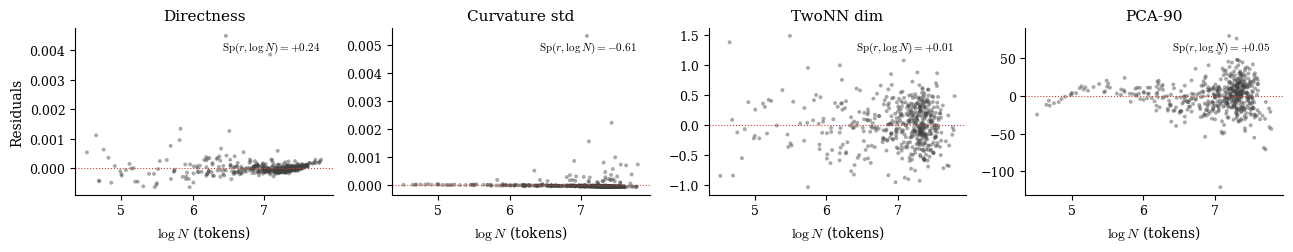

In [7]:
df_r = pd.read_parquet(DATA / '03_residual_diagnostics.parquet')
metrics_order = ['Directness', 'Curvature std', 'TwoNN dim', 'PCA-90']
fig, axes = plt.subplots(1, 4, figsize=(13, 2.6))
for ax, m in zip(axes, metrics_order):
    sub = df_r[df_r['metric'] == m]
    ax.scatter(sub['log_n'], sub['residual'], s=8, color='0.25', alpha=0.45, edgecolor='none')
    ax.axhline(0, color='#C8423B', ls=':', lw=0.8)
    ax.set_title(m)
    ax.set_xlabel(r'$\log N$ (tokens)')
    rho = sub['spearman_rho'].iloc[0]
    ax.text(0.95, 0.93, rf'$\mathrm{{Sp}}(r, \log N) = {rho:+.2f}$',
            transform=ax.transAxes, ha='right', va='top', fontsize=8)
axes[0].set_ylabel('Residuals')
fig.tight_layout()
fig.savefig(OUT_FIGS / 'cubic_log_residuals.pdf', bbox_inches='tight')
fig.savefig(OUT_FIGS / 'cubic_log_residuals.png', dpi=150, bbox_inches='tight')
plt.show()


## Directness prefix sensitivity (`directness_prefix_sensitivity.pdf`)

ρ vs reasoning-phase prefix fraction τ, averaged within five matched pair-groups.


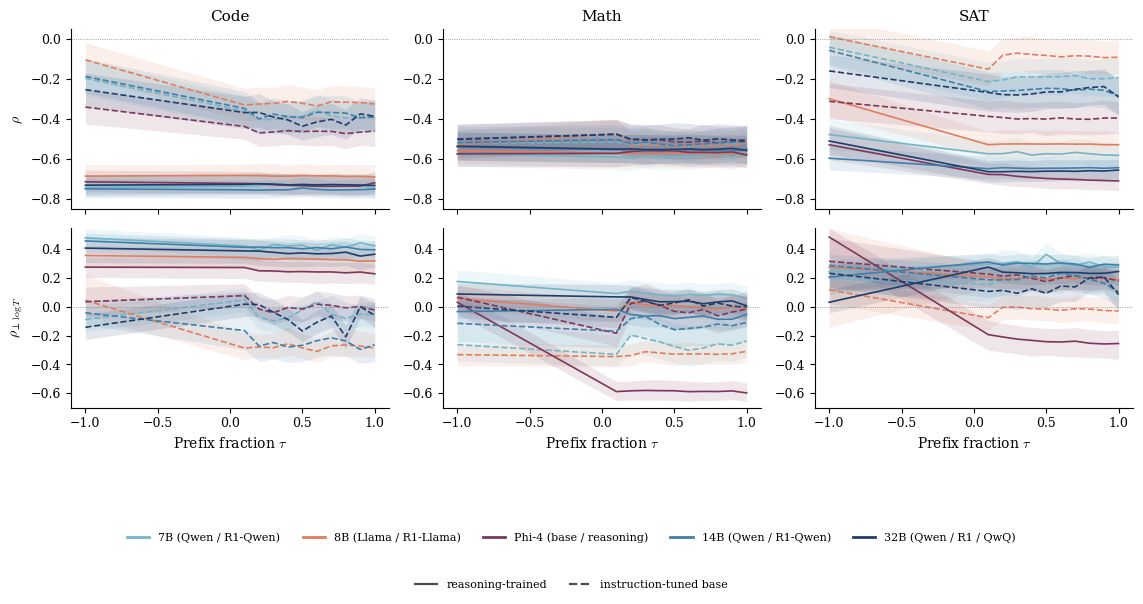

In [8]:
df_s = pd.read_parquet(DATA / '03_prefix_sensitivity.parquet')

PAIR_GROUPS = {
    '7B (Qwen / R1-Qwen)':   {'r1': ['deepseek-r1-7b'], 'base': ['qwen-7b'], 'color': '#73B5C7'},
    '8B (Llama / R1-Llama)': {'r1': ['r1-distill-llama-8b'], 'base': ['llama-8b'], 'color': '#E27D5C'},
    'Phi-4 (base / reasoning)': {'r1': ['phi-4-reasoning'], 'base': ['phi-4'], 'color': '#7D3759'},
    '14B (Qwen / R1-Qwen)':  {'r1': ['deepseek-r1-14b'], 'base': ['qwen-14b'], 'color': '#3E80AB'},
    '32B (Qwen / R1 / QwQ)': {'r1': ['deepseek-r1-32b', 'qwq-32b'], 'base': ['qwen-32b'], 'color': '#1F3D6C'},
}

fig, axes = plt.subplots(2, 3, figsize=(11.5, 5.2), sharex=True)
for row, (method, ylabel, ylim) in enumerate([
    ('raw', r'$\rho$', (-0.85, 0.05)),
    ('logtok', r'$\rho_{\perp\,\log T}$', (-0.7, 0.55)),
]):
    for col, dom in enumerate(DOMAIN_ORDER):
        ax = axes[row, col]
        for label, info in PAIR_GROUPS.items():
            for role, ls in [('r1', '-'), ('base', '--')]:
                models = info[role]
                sub = df_s[(df_s['domain'] == dom) & (df_s['model'].isin(models)) & (df_s['method'] == method)]
                if sub.empty:
                    continue
                grp = sub.groupby('frac', as_index=False)[['rho', 'lo', 'hi']].mean()
                ax.plot(grp['frac'], grp['rho'], ls=ls, color=info['color'], lw=1.2)
                ax.fill_between(grp['frac'], grp['lo'], grp['hi'], color=info['color'], alpha=0.12, lw=0)
        ax.axhline(0, color='0.5', ls=':', lw=0.6)
        ax.set_ylim(*ylim)
        if row == 0:
            ax.set_title(DOMAIN_LABEL[dom])
        if row == 1:
            ax.set_xlabel(r'Prefix fraction $\tau$')
    axes[row, 0].set_ylabel(ylabel)

color_handles = [plt.Line2D([0], [0], color=info['color'], lw=2, label=label)
                 for label, info in PAIR_GROUPS.items()]
style_handles = [plt.Line2D([0], [0], color='0.3', ls='-', lw=1.6, label='reasoning-trained'),
                 plt.Line2D([0], [0], color='0.3', ls='--', lw=1.6, label='instruction-tuned base')]
fig.legend(handles=color_handles, loc='lower center', ncol=5, frameon=False,
           bbox_to_anchor=(0.5, -0.07))
fig.legend(handles=style_handles, loc='lower center', ncol=2, frameon=False,
           bbox_to_anchor=(0.5, -0.16))
fig.tight_layout(rect=[0, 0.10, 1, 1])
fig.savefig(OUT_FIGS / 'directness_prefix_sensitivity.pdf', bbox_inches='tight')
fig.savefig(OUT_FIGS / 'directness_prefix_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()


## Per-method ρ⟂ summary


In [9]:
summary = df_v[df_v['metric'] == 'D'].pivot_table(
    index=['pair', 'role'], columns='method', values='rho_perp'
).round(3)
print(summary.to_string())


method         binned  cubic-log  invsqrt    log  loglog    raw
pair     role                                                  
Llama-8B base   0.110      0.168    0.044 -0.063  -0.087 -0.207
         r1     0.043      0.067    0.244  0.231  -0.161 -0.512
Phi-4    base   0.025      0.072    0.146  0.115   0.029 -0.380
         r1     0.066     -0.009    0.302  0.252  -0.192 -0.604
QwQ-32B  r1    -0.033     -0.016    0.351  0.252  -0.051 -0.641
Qwen-14B base   0.059      0.078    0.079  0.046  -0.005 -0.255
         r1    -0.059     -0.159    0.238  0.200  -0.218 -0.624
Qwen-32B base   0.039      0.064    0.077  0.048   0.056 -0.297
         r1    -0.080     -0.098    0.114  0.085  -0.203 -0.537
Qwen-7B  base   0.058      0.078    0.036 -0.032  -0.064 -0.246
         r1     0.020      0.038    0.273  0.298  -0.120 -0.591
